
# Apple Stock Analysis using Python

This project analyzes Apple (AAPL) stock data using Python and common financial analysis libraries.

## Objectives
- Retrieve historical stock price data
- Calculate daily returns
- Measure volatility and risk
- Analyze cumulative performance
- Visualize trends and return distributions

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- yfinance



### Daily Returns
Measures the percentage change in stock price from one day to the next.

### Cumulative Returns
Shows the total growth of an investment over time.

### Rolling Moving Average
Helps identify trend direction by smoothing short-term price fluctuations.

### Rolling Volatility
Measures how volatile the stock becomes over a moving time window.

### Sharpe Ratio (Simplified)
Evaluates risk-adjusted returns by comparing average return against volatility.



In [3]:

import yfinance as yf
import pandas as pd
import numpy as np

# Download stock data and prepare daily returns
data = yf.download("AAPL", start="2024-01-01")
data["Daily Return"] = data["Close"].pct_change()
data = data.dropna()

# Additional Financial Metrics

# Cumulative Returns
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()

# 20-Day Moving Average
data['20D_MA'] = data['Close'].rolling(window=20).mean()

# 20-Day Rolling Volatility
data['20D_Volatility'] = data['Daily Return'].rolling(window=20).std()

# Simplified Sharpe Ratio
risk_free_rate = 0.02 / 252  # Approx daily risk-free rate
sharpe_ratio = ((data['Daily Return'].mean() - risk_free_rate) / 
                data['Daily Return'].std()) * (252 ** 0.5)

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


[*********************100%***********************]  1 of 1 completed

Sharpe Ratio: 0.88



## Trend and Risk Visualization

The following charts help visualize:
- Long-term stock growth
- Trend smoothing using moving averages
- Changes in market volatility


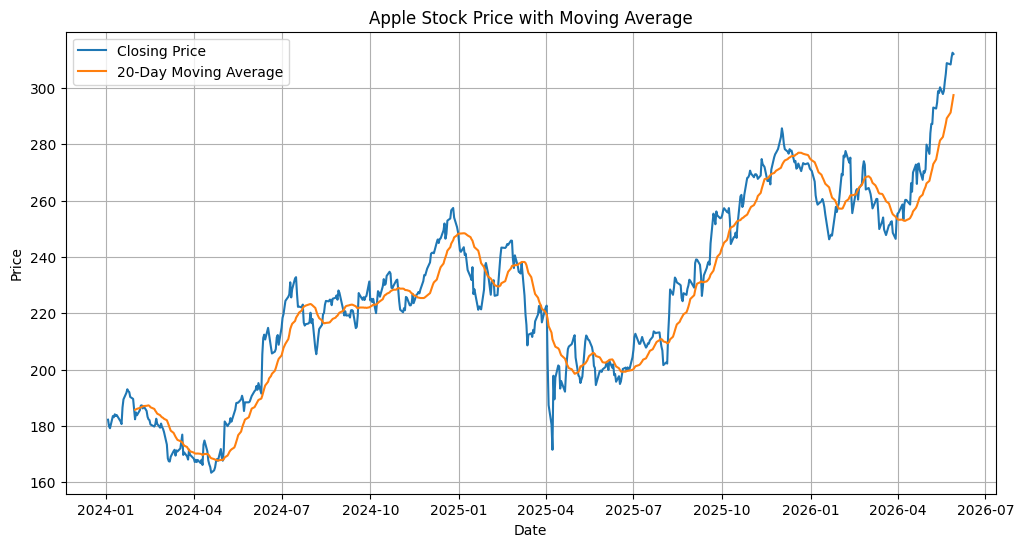

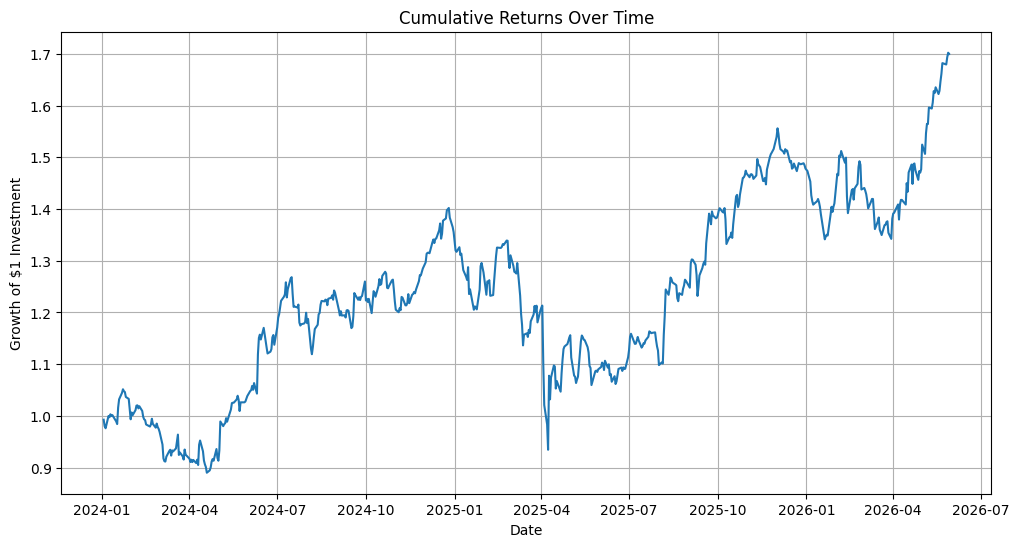

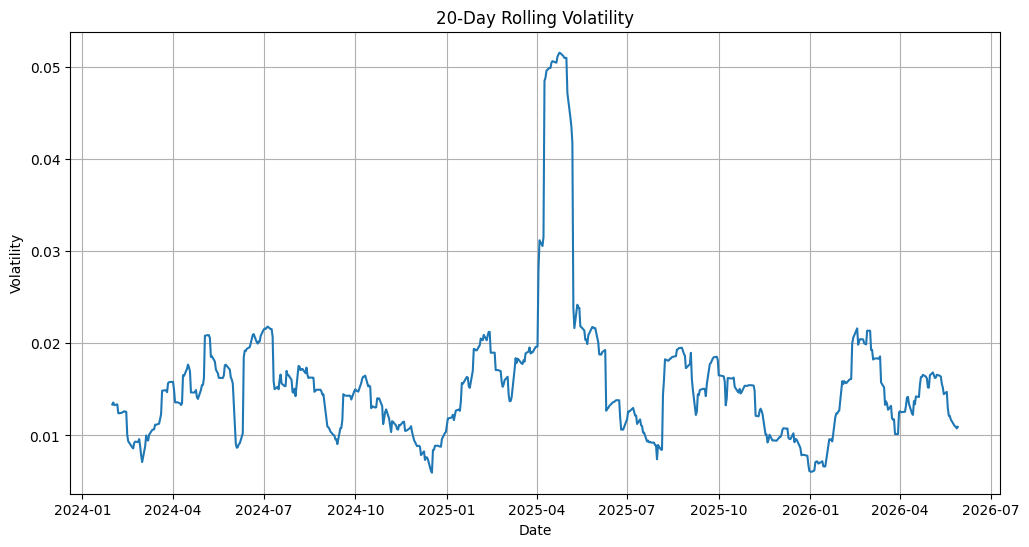

In [4]:

import matplotlib.pyplot as plt

# Plot Closing Price and Moving Average
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Closing Price')
plt.plot(data['20D_MA'], label='20-Day Moving Average')
plt.title('Apple Stock Price with Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot Cumulative Returns
plt.figure(figsize=(12,6))
plt.plot(data['Cumulative Return'])
plt.title('Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Growth of $1 Investment')
plt.grid(True)
plt.show()

# Plot Rolling Volatility
plt.figure(figsize=(12,6))
plt.plot(data['20D_Volatility'])
plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()


In [5]:
import yfinance as yf
apple = yf.download("AAPL", start="2024-01-01")
apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873962,181.040748,178.855492,180.111267,71983600
2024-01-05,179.152115,180.714432,178.153425,179.953062,62379700
2024-01-08,183.483109,183.522669,179.468553,180.051945,59144500


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
apple = yf.download("AAPL", start="2024-01-01")
apple.head()
apple.tail()
apple.columns
apple["Close"]

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
2024-01-02,183.562180
2024-01-03,182.187744
2024-01-04,179.873917
2024-01-05,179.152100
2024-01-08,183.483078
...,...
2026-05-22,308.820007
2026-05-26,308.329987
2026-05-27,310.850006
2026-05-28,312.510010


In [8]:
apple

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873917,181.040702,178.855446,180.111221,71983600
2024-01-05,179.152100,180.714417,178.153410,179.953046,62379700
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500
...,...,...,...,...,...
2026-05-22,308.820007,311.399994,305.839996,306.119995,43670200
2026-05-26,308.329987,311.820007,307.670013,309.559998,48000500
2026-05-27,310.850006,313.260010,308.299988,308.329987,50430900


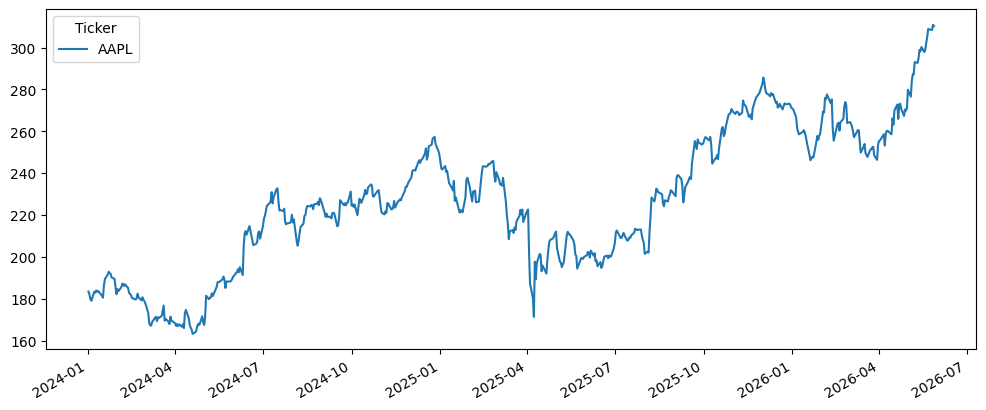

In [18]:
apple["Close"].plot(figsize=(12,5))

plt.show()

In [19]:
apple["Returns"] = apple["Close"].pct_change()

apple

Price,Close,High,Low,Open,Volume,Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
2024-01-02,183.562210,186.330874,181.831797,185.055304,82488700,NaN
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500,-0.007488
2024-01-04,179.873932,181.040717,178.855462,180.111236,71983600,-0.012700
2024-01-05,179.152084,180.714402,178.153394,179.953031,62379700,-0.004013
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500,0.024175
...,...,...,...,...,...,...
2026-05-21,304.989990,305.540009,300.399994,301.059998,42965100,0.009065
2026-05-22,308.820007,311.399994,305.839996,306.119995,43670200,0.012558
2026-05-26,308.329987,311.820007,307.670013,309.559998,48000500,-0.001587


In [20]:
apple["Returns"].mean()

np.float64(0.001017938102891535)

In [21]:
apple["Returns"].std()

np.float64(0.01716067876531274)

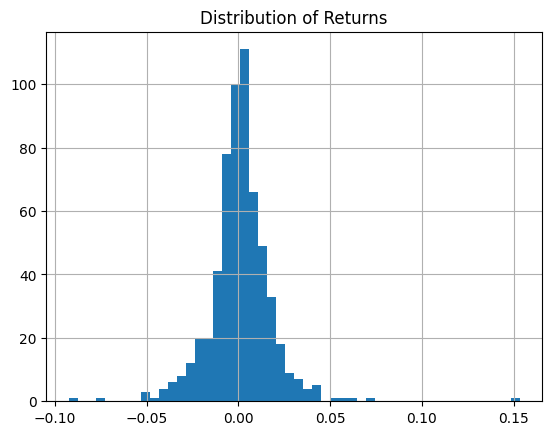

In [22]:
apple["Returns"].hist(bins=50)

plt.title("Distribution of Returns")
plt.show()

In [23]:
numbers = np.array([1,2,3,4,5])

numbers.mean()

np.float64(3.0)